# Phase 9: Training Analysis Notebook

This notebook loads training metrics from log files and generates visualizations to analyze:
- Training progress and convergence
- Comparison between baseline and shaped reward functions
- Statistical summaries of training performance
- Learning curves and trends

## 1. Import Required Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# Set style for better-looking plots
sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 10

## 2. Load Log Files

In [2]:
# Set up paths
logs_dir = Path('../logs')
logs_dir.mkdir(exist_ok=True)

# Load training metrics CSV files
baseline_metrics_path = logs_dir / 'training_metrics_baseline.csv'
shaped_metrics_path = logs_dir / 'training_metrics_shaped.csv'

# Load available log files
logs_data = {}

if baseline_metrics_path.exists():
    logs_data['baseline'] = pd.read_csv(baseline_metrics_path)
    print(f"✓ Loaded baseline metrics: {baseline_metrics_path}")
    print(f"  Shape: {logs_data['baseline'].shape}")
else:
    print(f"✗ Baseline metrics not found: {baseline_metrics_path}")

if shaped_metrics_path.exists():
    logs_data['shaped'] = pd.read_csv(shaped_metrics_path)
    print(f"✓ Loaded shaped metrics: {shaped_metrics_path}")
    print(f"  Shape: {logs_data['shaped'].shape}")
else:
    print(f"✗ Shaped metrics not found: {shaped_metrics_path}")

# Display available data
print(f"\nTotal logs loaded: {len(logs_data)}")
if logs_data:
    print(f"Available reward types: {list(logs_data.keys())}")

✓ Loaded baseline metrics: ..\logs\training_metrics_baseline.csv
  Shape: (32, 2)
✓ Loaded shaped metrics: ..\logs\training_metrics_shaped.csv
  Shape: (16, 2)

Total logs loaded: 2
Available reward types: ['baseline', 'shaped']


## 3. Parse and Clean Log Data

In [3]:
# Clean and prepare data
cleaned_data = {}

for reward_type, df in logs_data.items():
    print(f"\nProcessing {reward_type} data:")
    
    # Check for missing values
    missing = df.isnull().sum()
    if missing.any():
        print(f"  Missing values detected: {missing[missing > 0].to_dict()}")
        df = df.dropna()
    
    # Check for duplicates
    duplicates = df.duplicated().sum()
    if duplicates > 0:
        print(f"  Removing {duplicates} duplicate rows")
        df = df.drop_duplicates()
    
    # Ensure numeric types
    df['timesteps'] = pd.to_numeric(df['timesteps'], errors='coerce')
    df['mean_reward'] = pd.to_numeric(df['mean_reward'], errors='coerce')
    
    # Sort by timesteps
    df = df.sort_values('timesteps').reset_index(drop=True)
    
    cleaned_data[reward_type] = df
    print(f"  Final shape: {df.shape}")
    print(f"  Timesteps range: {df['timesteps'].min():.0f} to {df['timesteps'].max():.0f}")
    print(f"  Mean reward range: {df['mean_reward'].min():.4f} to {df['mean_reward'].max():.4f}")


Processing baseline data:
  Final shape: (32, 2)
  Timesteps range: 1 to 32
  Mean reward range: 1.7293 to 1.9997

Processing shaped data:
  Final shape: (16, 2)
  Timesteps range: 1 to 16
  Mean reward range: 1.8911 to 1.9986


## 4. Generate Summary Statistics

In [4]:
# Calculate summary statistics for each reward type
summary_stats = {}

for reward_type, df in cleaned_data.items():
    rewards = df['mean_reward']
    summary_stats[reward_type] = {
        'Count': len(rewards),
        'Mean': rewards.mean(),
        'Median': rewards.median(),
        'Std Dev': rewards.std(),
        'Min': rewards.min(),
        'Max': rewards.max(),
        'Q1 (25%)': rewards.quantile(0.25),
        'Q3 (75%)': rewards.quantile(0.75),
    }

# Create summary table
summary_df = pd.DataFrame(summary_stats).T
print("\n=== SUMMARY STATISTICS ===\n")
print(summary_df.round(4))

# Calculate improvement metrics if both types exist
if len(cleaned_data) == 2:
    baseline_final = cleaned_data['baseline']['mean_reward'].iloc[-1]
    shaped_final = cleaned_data['shaped']['mean_reward'].iloc[-1]
    improvement = ((shaped_final - baseline_final) / abs(baseline_final)) * 100
    
    print(f"\n=== COMPARATIVE ANALYSIS ===")
    print(f"Baseline final reward: {baseline_final:.4f}")
    print(f"Shaped final reward: {shaped_final:.4f}")
    print(f"Improvement: {improvement:+.2f}%")


=== SUMMARY STATISTICS ===

          Count    Mean  Median  Std Dev     Min     Max  Q1 (25%)  Q3 (75%)
baseline   32.0  1.9473  1.9908   0.0782  1.7293  1.9997    1.9232    1.9990
shaped     16.0  1.9560  1.9635   0.0314  1.8911  1.9986    1.9379    1.9776

=== COMPARATIVE ANALYSIS ===
Baseline final reward: 1.9996
Shaped final reward: 1.8911
Improvement: -5.43%


## 5. Create Visualization Plots

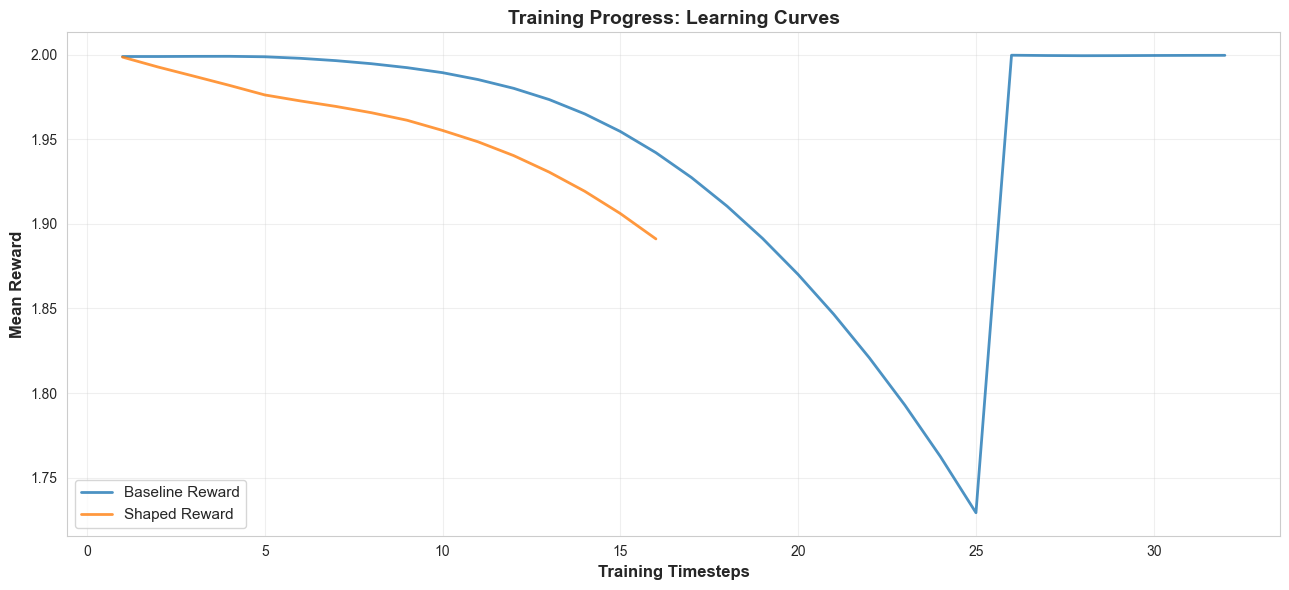

✓ Learning curves plot generated


In [5]:
### Plot 1: Learning Curves Comparison
fig, axes = plt.subplots(1, 1, figsize=(13, 6))

colors = {'baseline': '#1f77b4', 'shaped': '#ff7f0e'}

for reward_type, df in cleaned_data.items():
    axes.plot(df['timesteps'], df['mean_reward'], 
              label=f"{reward_type.capitalize()} Reward", 
              color=colors[reward_type], linewidth=2, alpha=0.8)

axes.set_xlabel('Training Timesteps', fontsize=12, fontweight='bold')
axes.set_ylabel('Mean Reward', fontsize=12, fontweight='bold')
axes.set_title('Training Progress: Learning Curves', fontsize=14, fontweight='bold')
axes.legend(fontsize=11, loc='best')
axes.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("✓ Learning curves plot generated")

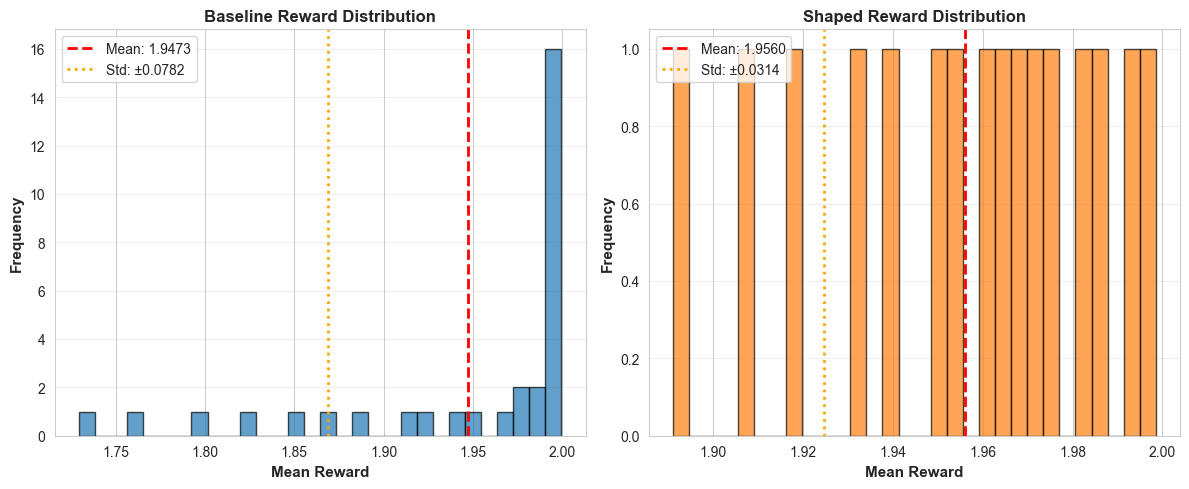

✓ Reward distribution histograms generated


In [6]:
### Plot 2: Reward Distribution Histograms
if len(cleaned_data) > 0:
    fig, axes = plt.subplots(1, len(cleaned_data), figsize=(6*len(cleaned_data), 5))
    
    if len(cleaned_data) == 1:
        axes = [axes]
    
    for idx, (reward_type, df) in enumerate(cleaned_data.items()):
        axes[idx].hist(df['mean_reward'], bins=30, color=colors[reward_type], alpha=0.7, edgecolor='black')
        axes[idx].set_xlabel('Mean Reward', fontsize=11, fontweight='bold')
        axes[idx].set_ylabel('Frequency', fontsize=11, fontweight='bold')
        axes[idx].set_title(f'{reward_type.capitalize()} Reward Distribution', fontsize=12, fontweight='bold')
        axes[idx].grid(True, alpha=0.3, axis='y')
        
        # Add statistics text
        mean_val = df['mean_reward'].mean()
        std_val = df['mean_reward'].std()
        axes[idx].axvline(mean_val, color='red', linestyle='--', linewidth=2, label=f'Mean: {mean_val:.4f}')
        axes[idx].axvline(mean_val - std_val, color='orange', linestyle=':', linewidth=2, label=f'Std: ±{std_val:.4f}')
        axes[idx].legend(fontsize=10)
    
    plt.tight_layout()
    plt.show()
    print("✓ Reward distribution histograms generated")

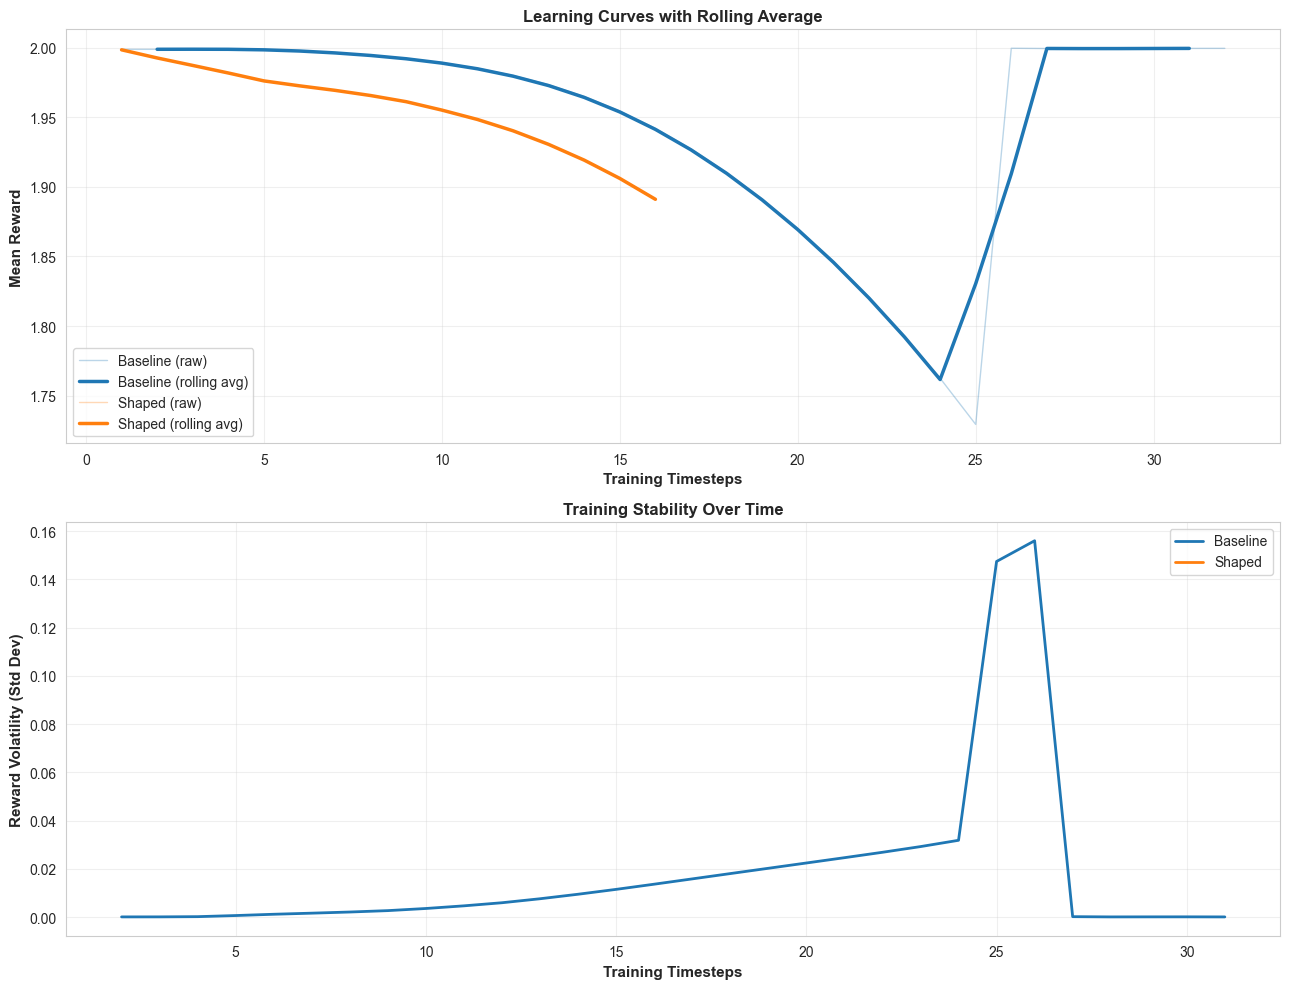

✓ Running statistics plots generated


In [7]:
### Plot 3: Running Average and Volatility
if len(cleaned_data) > 0:
    fig, axes = plt.subplots(2, 1, figsize=(13, 10))
    
    for reward_type, df in cleaned_data.items():
        # Calculate rolling average (window=10)
        window = max(1, len(df) // 10)
        rolling_avg = df['mean_reward'].rolling(window=window, center=True).mean()
        rolling_std = df['mean_reward'].rolling(window=window, center=True).std()
        
        # Plot 1: Learning curve with rolling average
        axes[0].plot(df['timesteps'], df['mean_reward'], 
                    label=f"{reward_type.capitalize()} (raw)", 
                    color=colors[reward_type], alpha=0.3, linewidth=1)
        axes[0].plot(df['timesteps'], rolling_avg, 
                    label=f"{reward_type.capitalize()} (rolling avg)", 
                    color=colors[reward_type], linewidth=2.5)
        
        # Plot 2: Volatility over time
        axes[1].plot(df['timesteps'], rolling_std, 
                    label=f"{reward_type.capitalize()}", 
                    color=colors[reward_type], linewidth=2)
    
    # Format Plot 1
    axes[0].set_xlabel('Training Timesteps', fontsize=11, fontweight='bold')
    axes[0].set_ylabel('Mean Reward', fontsize=11, fontweight='bold')
    axes[0].set_title('Learning Curves with Rolling Average', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=10, loc='best')
    axes[0].grid(True, alpha=0.3)
    
    # Format Plot 2
    axes[1].set_xlabel('Training Timesteps', fontsize=11, fontweight='bold')
    axes[1].set_ylabel('Reward Volatility (Std Dev)', fontsize=11, fontweight='bold')
    axes[1].set_title('Training Stability Over Time', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=10, loc='best')
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()
    print("✓ Running statistics plots generated")

## 6. Export Analysis Results

In [8]:
# Export summary statistics to CSV
output_dir = Path('../logs')
output_dir.mkdir(exist_ok=True)

summary_output_path = output_dir / 'analysis_summary_statistics.csv'
summary_df.to_csv(summary_output_path)
print(f"✓ Summary statistics exported to: {summary_output_path}")

# Create comparison report
report_path = output_dir / 'training_analysis_report.txt'
with open(report_path, 'w') as f:
    f.write("=" * 60 + "\n")
    f.write("TRAINING ANALYSIS REPORT\n")
    f.write("=" * 60 + "\n\n")
    
    f.write("SUMMARY STATISTICS\n")
    f.write("-" * 60 + "\n")
    f.write(summary_df.round(4).to_string())
    f.write("\n\n")
    
    if len(cleaned_data) == 2:
        baseline_final = cleaned_data['baseline']['mean_reward'].iloc[-1]
        shaped_final = cleaned_data['shaped']['mean_reward'].iloc[-1]
        improvement = ((shaped_final - baseline_final) / abs(baseline_final)) * 100
        
        f.write("COMPARATIVE ANALYSIS\n")
        f.write("-" * 60 + "\n")
        f.write(f"Baseline final reward: {baseline_final:.4f}\n")
        f.write(f"Shaped final reward: {shaped_final:.4f}\n")
        f.write(f"Improvement: {improvement:+.2f}%\n")

print(f"✓ Analysis report exported to: {report_path}")

# Save cleaned data CSVs with analysis metadata
for reward_type, df in cleaned_data.items():
    df_copy = df.copy()
    df_copy['rolling_avg_reward'] = df_copy['mean_reward'].rolling(
        window=max(1, len(df_copy) // 10), center=True).mean()
    analysis_path = output_dir / f'analysis_{reward_type}_metrics.csv'
    df_copy.to_csv(analysis_path, index=False)
    print(f"✓ Enhanced metrics exported: {analysis_path}")

print("\n" + "=" * 60)
print("ANALYSIS COMPLETE")
print("=" * 60)

✓ Summary statistics exported to: ..\logs\analysis_summary_statistics.csv
✓ Analysis report exported to: ..\logs\training_analysis_report.txt
✓ Enhanced metrics exported: ..\logs\analysis_baseline_metrics.csv
✓ Enhanced metrics exported: ..\logs\analysis_shaped_metrics.csv

ANALYSIS COMPLETE
